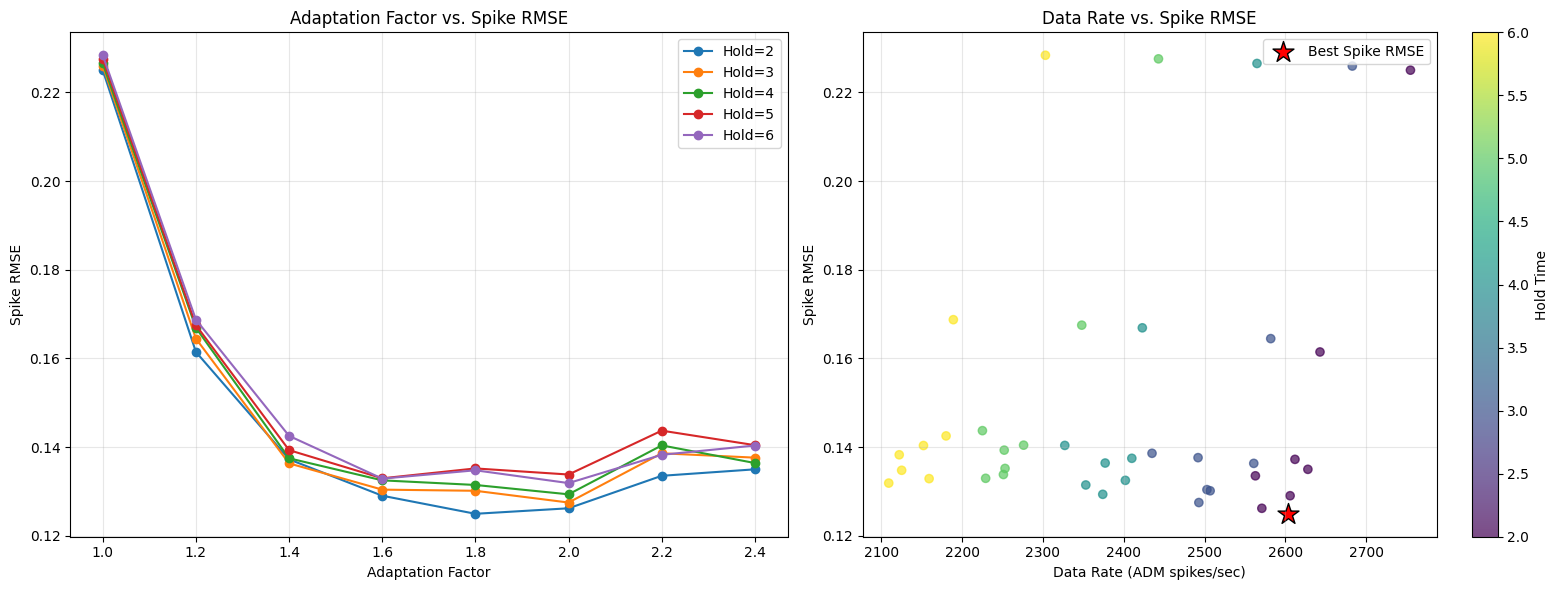

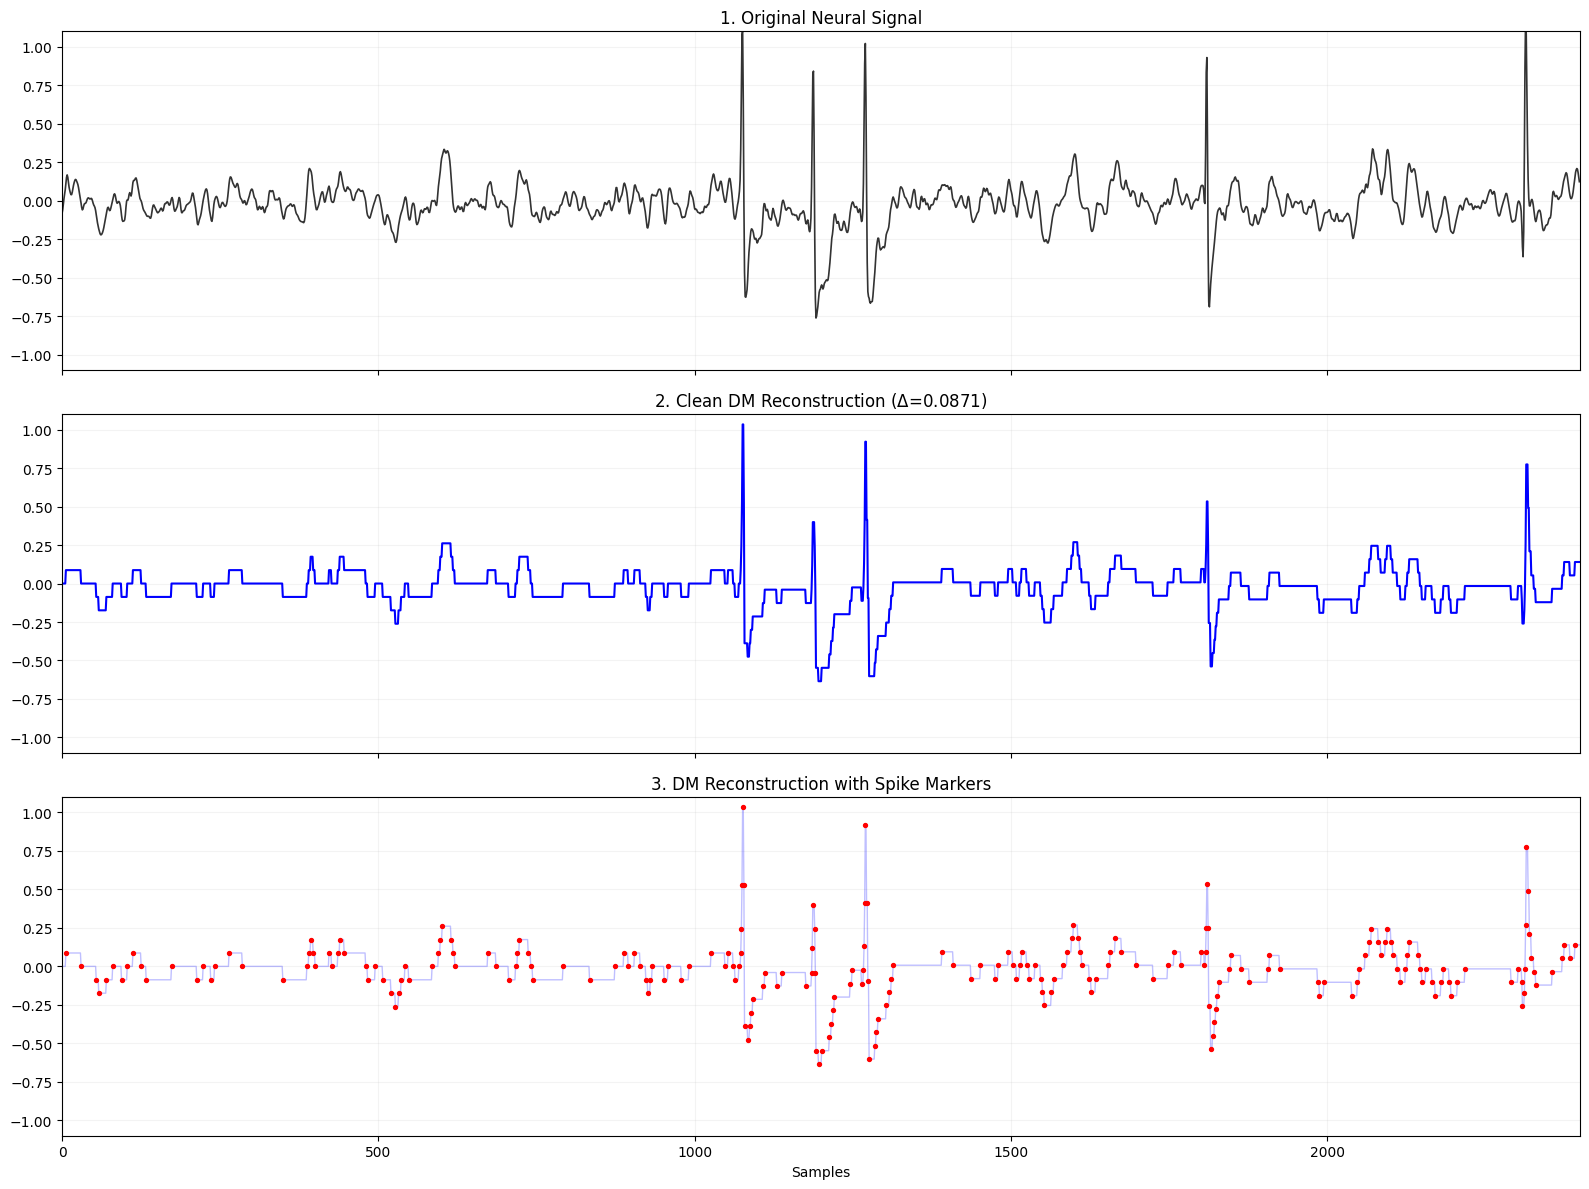


FINAL BEST RESULTS (SPIKE-SPECIFIC RMSE)
Adaptation Factor: 1.80
Hold Time:         2
Spike-Only RMSE:   0.124983
Spike-Only CC:     0.9372
Average Data Rate: 2604.00 spikes/sec


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.io import loadmat
import itertools

# ============================================================================
# 1. Load Data and Ground Truth
# ============================================================================
file_path = './C_Difficult1_noise01.mat'

try:
    MAT = loadmat(file_path)
    # Note: Structure can vary; adjusting to common simulator format
    rawData = np.array(MAT['data'])[0]
    sampling_interval = np.array(MAT['samplingInterval'][0][0]) * 1e-3
    sample_rate = int(1 / sampling_interval)
    
    # Ground Truth Spike Times (adjust indexing if nested differently)
    # Using the structure provided in your prompt
    spikeTimeGT = np.array(MAT['spike_times'][0][0][0]) 
    
    data = rawData[:int(sample_rate)] # Analyzing first 1 second
except Exception as e:
    print(f"Error loading file: {e}. Generating dummy data for demonstration.")
    sample_rate = 25000
    data = np.random.normal(0, 0.1, sample_rate)
    spikeTimeGT = np.array([500, 1200, 5000, 18000]) # Dummy spike indices

# ============================================================================
# 2. ADM Logic & Specialized Evaluation
# ============================================================================

def spike_aware_adm(x, min_delta, adaptation_factor, noise_floor, hold_time):
    y = np.zeros_like(x)
    spikes = []
    current_delta = min_delta  
    y[0] = 0
    active_hold = 0
    
    for n in range(1, len(x)):
        pred = y[n-1]
        diff = x[n] - pred
        
        # Deadzone / Noise Floor check
        if abs(diff) < noise_floor:
            y[n] = pred
            current_delta = max(current_delta / adaptation_factor, min_delta)
            if active_hold > 0: 
                active_hold -= 1
                continue
            
        if diff > current_delta:
            y[n] = pred + current_delta
            spikes.append((n, 1))
            current_delta *= adaptation_factor 
            active_hold = hold_time
        elif diff < -current_delta:
            y[n] = pred - current_delta
            spikes.append((n, -1))
            current_delta *= adaptation_factor 
            active_hold = hold_time
        else:
            y[n] = pred
            current_delta = max(current_delta / adaptation_factor, min_delta)
            if active_hold > 0: active_hold -= 1
            
    return y, spikes
def spk_rmse_eval(data, reconstructed_signal, spikeTimeGT, window_size=48):
    data_spk = []
    reconstructed_spk = []
    
    # Filter GT spikes that fit within the current data length
    valid_spikes = spikeTimeGT[spikeTimeGT < (len(data) - window_size)]
    
    for i in valid_spikes:
        # Reconstructed window [i : i+48]
        rec_section = reconstructed_signal[i : i + window_size]
        # Data window shifted by 1 to account for ADM 1-sample delay [i-1 : i+47]
        data_section = data[i - 1 : i + window_size - 1]
        
        data_spk.extend(data_section)
        reconstructed_spk.extend(rec_section)
    
    data_spk = np.array(data_spk)
    reconstructed_spk = np.array(reconstructed_spk)
    
    if len(data_spk) == 0: return 999, 0 # Fallback
    
    rmse = np.sqrt(np.mean((data_spk - reconstructed_spk)**2))
    nrmse = rmse / (np.ptp(data_spk) + 1e-9)
    cc = np.corrcoef(data_spk, reconstructed_spk)[0, 1]
    
    return rmse, nrmse, cc

# ============================================================================
# 3. Parameter Sweep (Optimizing for Spike RMSE)
# ============================================================================
hold_times = np.arange(2, 7, 1)
adaptation_factors = np.arange(1.0, 2.6, 0.2)
noise_thr = 2.5 * np.median(np.abs(data - np.median(data)))
fixed_min_delta = noise_thr * 0.5

results = []
for h_time, factor in itertools.product(hold_times, adaptation_factors):
    y_rec, spikes = spike_aware_adm(data, fixed_min_delta, factor, noise_thr, h_time)
    
    # Use the new Spike-specific RMSE
    s_rmse, s_nrmse, s_cc = spk_rmse_eval(data, y_rec, spikeTimeGT)
    
    results.append({
        "hold_time": h_time, 
        "factor": factor, 
        "SpikeRMSE": s_rmse,
        "SpikeCC": s_cc,
        "DataRate": len(spikes) / (len(data)/sample_rate),
        "spikes": spikes,
        "y": y_rec
    })

df = pd.DataFrame(results)
best_res = df.loc[df['SpikeRMSE'].idxmin()]

# ============================================================================
# 4. Visualization
# ============================================================================

# --- FIGURE 1: Parameter Sweep Analysis (Spike-Focused) ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: How Adaptation Factor affects Spike RMSE
for h in hold_times:
    subset = df[df['hold_time'] == h]
    # We use 'SpikeRMSE' now as our primary quality metric
    ax1.plot(subset['factor'], subset['SpikeRMSE'], 'o-', label=f"Hold={h}")

ax1.set_title("Adaptation Factor vs. Spike RMSE")
ax1.set_xlabel("Adaptation Factor")
ax1.set_ylabel("Spike RMSE")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Pareto-like view (Data Rate vs. Signal Quality)
scatter = ax2.scatter(df['DataRate'], df['SpikeRMSE'], c=df['hold_time'], cmap='viridis', alpha=0.7)
ax2.scatter(best_res['DataRate'], best_res['SpikeRMSE'], color='red', marker='*', s=250, 
            edgecolor='black', label="Best Spike RMSE")

plt.colorbar(scatter, ax=ax2, label='Hold Time')
ax2.set_title("Data Rate vs. Spike RMSE")
ax2.set_xlabel("Data Rate (ADM spikes/sec)")
ax2.set_ylabel("Spike RMSE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# ============================================================================
# 4. Visualization (Formatted to match output2.png)
# ============================================================================

# Define the number of samples for 1 second
num_samples = int(0.1 * sample_rate)

# Ensure we are only plotting the first second of results
# (Note: data and best_res['y'] are already 1s long based on your loading code)
time_indices = np.arange(num_samples)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# --- 1. Original Neural Signal ---
ax1.plot(time_indices, data[:num_samples], color='#333333', lw=1.2)
ax1.set_title("1. Original Neural Signal", fontsize=12)
ax1.set_xlim([0, num_samples])
ax1.set_ylim([-1.1, 1.1])
ax1.grid(True, which='both', linestyle='-', alpha=0.15)

# --- 2. Clean DM Reconstruction ---
ax2.plot(time_indices, best_res['y'][:num_samples], color='blue', lw=1.5)
ax2.set_title(f"2. Clean DM Reconstruction ($\Delta$={fixed_min_delta:.4f})", fontsize=12)
ax2.set_ylim([-1.1, 1.1])
ax2.grid(True, which='both', linestyle='-', alpha=0.15)

# --- 3. DM Reconstruction with Spike Markers ---
# Plot the reconstruction as a faint line
ax3.plot(time_indices, best_res['y'][:num_samples], color='blue', alpha=0.25, lw=1)

# Filter spikes that occurred within the first second
spikes_in_1s = [s for s in best_res['spikes'] if s[0] < num_samples]
spike_idx = [s[0] for s in spikes_in_1s]
spike_val = [best_res['y'][s[0]] for s in spikes_in_1s]

# Overlay red dots
ax3.scatter(spike_idx, spike_val, color='red', s=8, zorder=5)
ax3.set_title("3. DM Reconstruction with Spike Markers", fontsize=12)
ax3.set_xlabel("Samples") # Added label to match the PNG style
ax3.set_ylim([-1.1, 1.1])
ax3.grid(True, which='both', linestyle='-', alpha=0.15)

plt.tight_layout()
plt.show()

# ============================================================================
# 5. Summary Output (Updated to reflect Spike-Specific metrics)
# ============================================================================
print("\n" + "="*60)
print("FINAL BEST RESULTS (SPIKE-SPECIFIC RMSE)")
print("="*60)
print(f"Adaptation Factor: {best_res['factor']:.2f}")
print(f"Hold Time:         {best_res['hold_time']}")
print(f"Spike-Only RMSE:   {best_res['SpikeRMSE']:.6f}")
print(f"Spike-Only CC:     {best_res['SpikeCC']:.4f}")
print(f"Average Data Rate: {best_res['DataRate']:.2f} spikes/sec")
print("="*60)




Processing Noise 005...
Processing Noise 01...
Processing Noise 015...
Processing Noise 02...


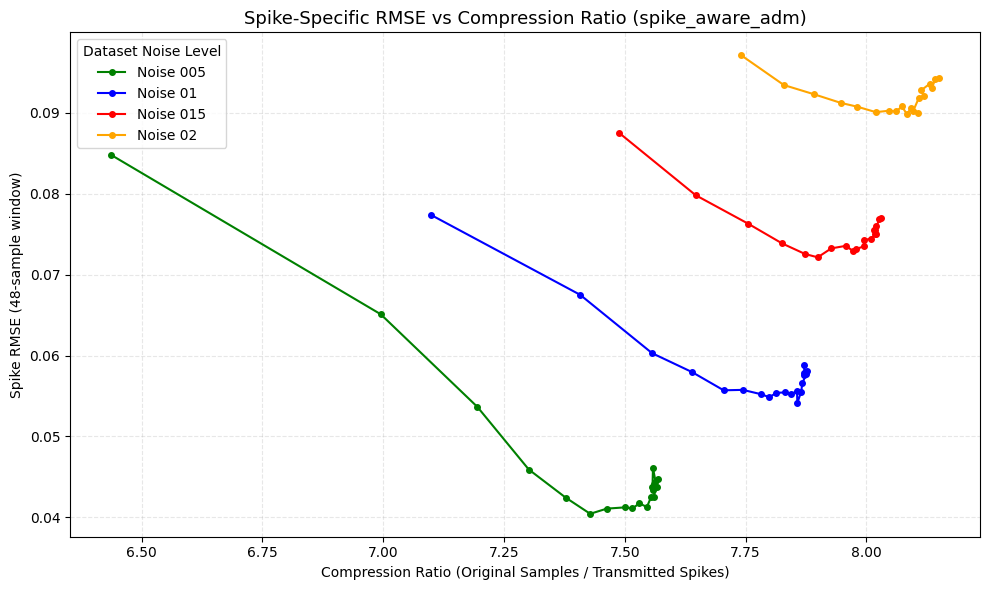

In [2]:
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
import itertools

# ============================================================================
# 1. Core Logic Functions (From Your Latest Code)
# ============================================================================

def spike_aware_adm(x, min_delta, adaptation_factor, noise_floor, hold_time):
    y = np.zeros_like(x)
    spikes_count = 0
    current_delta = min_delta  
    y[0] = 0
    active_hold = 0
    
    for n in range(1, len(x)):
        pred = y[n-1]
        diff = x[n] - pred
        
        if abs(diff) < noise_floor:
            y[n] = pred
            current_delta = max(current_delta / adaptation_factor, min_delta)
            if active_hold > 0: 
                active_hold -= 1
                continue
            
        if diff > current_delta:
            y[n] = pred + current_delta
            spikes_count += 1
            current_delta *= adaptation_factor 
            active_hold = hold_time
        elif diff < -current_delta:
            y[n] = pred - current_delta
            spikes_count += 1
            current_delta *= adaptation_factor 
            active_hold = hold_time
        else:
            y[n] = pred
            current_delta = max(current_delta / adaptation_factor, min_delta)
            if active_hold > 0: active_hold -= 1
            
    return y, spikes_count

def spk_rmse_eval(data, reconstructed_signal, spikeTimeGT, window_size=48):
    data_spk, reconstructed_spk = [], []
    # Filter GT spikes that fit within data bounds
    valid_spikes = spikeTimeGT[(spikeTimeGT >= 1) & (spikeTimeGT < (len(data) - window_size))]
    
    for i in valid_spikes:
        idx = int(i)
        # Shift data by 1 to account for ADM 1-sample delay as in your latest code
        data_section = data[idx - 1 : idx + window_size - 1]
        rec_section = reconstructed_signal[idx : idx + window_size]
        data_spk.extend(data_section)
        reconstructed_spk.extend(rec_section)
        
    if len(data_spk) == 0: return 999
    return np.sqrt(np.mean((np.array(data_spk) - np.array(reconstructed_spk))**2))

def estimate_noise_floor(x, factor=2.5):
    mad = np.median(np.abs(x - np.median(x)))
    return factor * mad

# ==========================================
# 2. Configuration & Parameter Sweep Setup
# ==========================================

noise_sets = {
    "Noise 005": ["C_Easy1_noise005.mat", "C_Easy2_noise005.mat", "C_Difficult1_noise005.mat", "C_Difficult2_noise005.mat"],
    "Noise 01":  ["C_Easy1_noise01.mat", "C_Easy2_noise01.mat", "C_Difficult1_noise01.mat", "C_Difficult2_noise01.mat"],
    "Noise 015": ["C_Easy1_noise015.mat", "C_Easy2_noise015.mat", "C_Difficult1_noise015.mat", "C_Difficult2_noise015.mat"],
    "Noise 02":  ["C_Easy1_noise02.mat", "C_Easy2_noise02.mat", "C_Difficult1_noise02.mat", "C_Difficult2_noise02.mat"]
}

sample_rate = 24000
# Sweep adaptation factors to generate the curve
adaptation_factors = np.linspace(1.01, 2.8, 20) 
fixed_hold_time = 4

plt.figure(figsize=(10, 6))
colors = {"Noise 005": "green", "Noise 01": "blue", "Noise 015": "red", "Noise 02": "orange"}

# ==========================================
# 3. Processing and Averaging
# ==========================================

for label, files in noise_sets.items():
    all_file_rmse = []
    all_file_cr = []
    
    print(f"Processing {label}...")
    
    for filename in files:
        try:
            mat = sio.loadmat(filename)
            raw_sig = mat['data'].flatten()
            
            # Ground Truth Spike Indices (from Quiroga ms times)
            st_cell = mat['spike_times']
            spike_indices = []
            for i in range(st_cell.shape[1]):
                times_ms = st_cell[0, i].flatten()
                indices = np.round((times_ms / 1000.0) * sample_rate).astype(int)
                spike_indices.extend(indices)
            spike_indices = np.sort(np.unique(spike_indices))
            
            # Pre-Filter
            b, a = butter(4, [300*2/sample_rate, 5000*2/sample_rate], btype='band')
            data = lfilter(b, a, raw_sig)
            
            # ADM Setup
            noise_thr = estimate_noise_floor(data)
            min_delta = noise_thr * 0.5
            
            file_rmse, file_cr = [], []
            for factor in adaptation_factors:
                y_rec, n_spikes = spike_aware_adm(data, min_delta, factor, noise_thr, fixed_hold_time)
                
                # Metric 1: Spike-only RMSE (48-sample window)
                rmse_val = spk_rmse_eval(data, y_rec, spike_indices)
                
                # Metric 2: Compression Ratio (Samples / Spikes)
                cr_val = len(data) / n_spikes if n_spikes > 0 else np.nan
                
                file_rmse.append(rmse_val)
                file_cr.append(cr_val)
            
            all_file_rmse.append(file_rmse)
            all_file_cr.append(file_cr)
            
        except Exception as e:
            print(f"Skipping {filename}: {e}")

    # Plot Averages for the Set
    if all_file_rmse:
        avg_rmse = np.nanmean(all_file_rmse, axis=0)
        avg_cr = np.nanmean(all_file_cr, axis=0)
        plt.plot(avg_cr, avg_rmse, '-o', markersize=4, label=label, color=colors[label])

# ==========================================
# 4. Final Plot Formatting
# ==========================================

plt.title("Spike-Specific RMSE vs Compression Ratio (spike_aware_adm)", fontsize=13)
plt.xlabel("Compression Ratio (Original Samples / Transmitted Spikes)")
plt.ylabel("Spike RMSE (48-sample window)")
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title="Dataset Noise Level")
plt.tight_layout()
plt.show()


--- Processing Hold Time: 2 ---
--- Processing Hold Time: 3 ---
--- Processing Hold Time: 4 ---
--- Processing Hold Time: 5 ---
--- Processing Hold Time: 6 ---


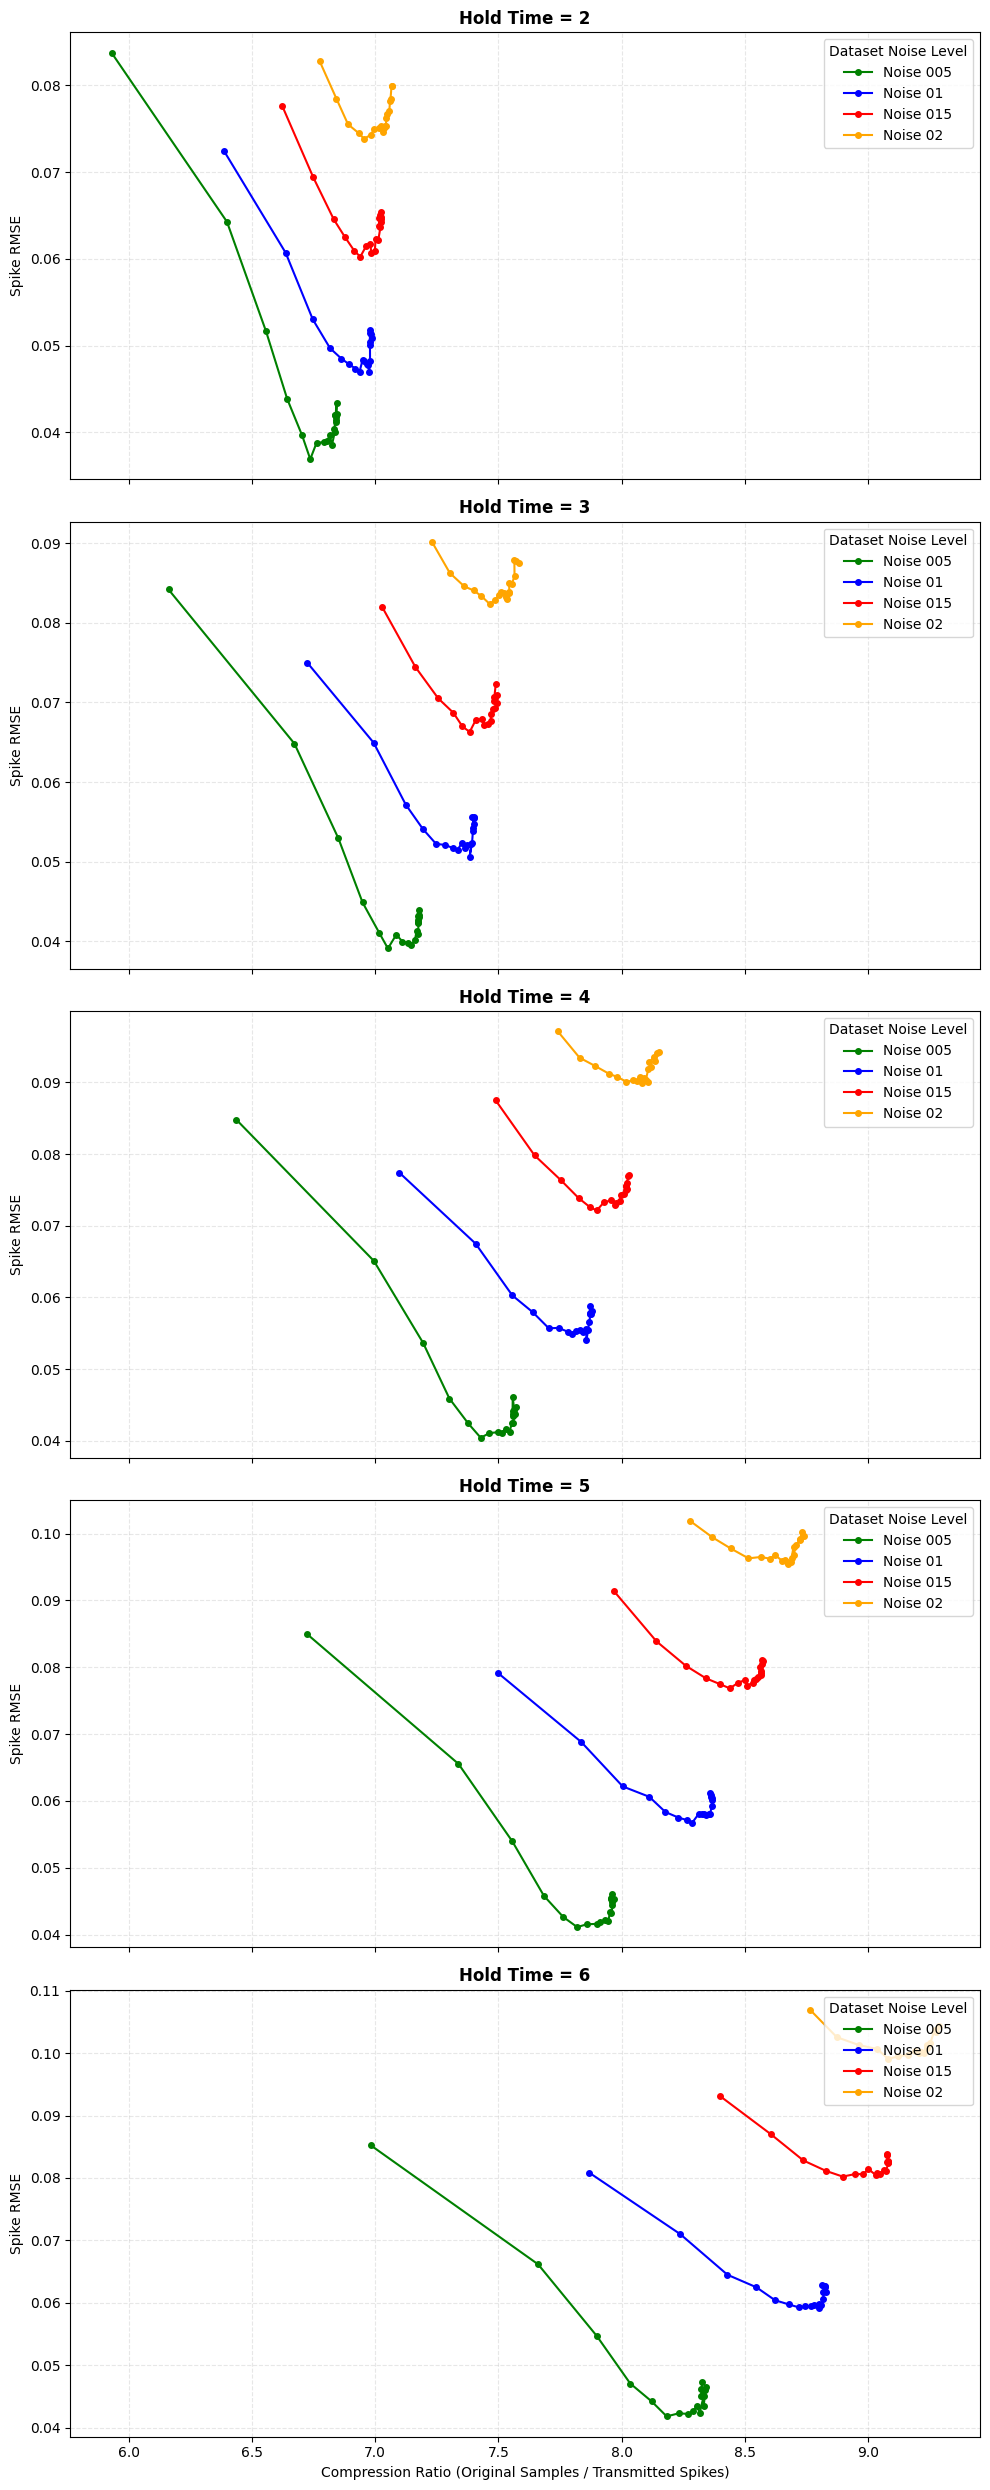

In [3]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# ... [Keep your spike_aware_adm, spk_rmse_eval, and estimate_noise_floor functions here] ...

# ==========================================
# 2. Configuration & Parameter Sweep Setup
# ==========================================
noise_sets = {
    "Noise 005": ["C_Easy1_noise005.mat", "C_Easy2_noise005.mat", "C_Difficult1_noise005.mat", "C_Difficult2_noise005.mat"],
    "Noise 01":  ["C_Easy1_noise01.mat", "C_Easy2_noise01.mat", "C_Difficult1_noise01.mat", "C_Difficult2_noise01.mat"],
    "Noise 015": ["C_Easy1_noise015.mat", "C_Easy2_noise015.mat", "C_Difficult1_noise015.mat", "C_Difficult2_noise015.mat"],
    "Noise 02":  ["C_Easy1_noise02.mat", "C_Easy2_noise02.mat", "C_Difficult1_noise02.mat", "C_Difficult2_noise02.mat"]
}

sample_rate = 24000
adaptation_factors = np.linspace(1.01, 2.8, 20) 
hold_times = range(2, 7)  # 2, 3, 4, 5, 6
colors = {"Noise 005": "green", "Noise 01": "blue", "Noise 015": "red", "Noise 02": "orange"}

# Create a figure with subplots (one for each hold time)
fig, axes = plt.subplots(len(hold_times), 1, figsize=(10, 5 * len(hold_times)), sharex=True)

# ==========================================
# 3. Processing and Averaging
# ==========================================

for idx, ht in enumerate(hold_times):
    print(f"--- Processing Hold Time: {ht} ---")
    ax = axes[idx]
    
    for label, files in noise_sets.items():
        all_file_rmse = []
        all_file_cr = []
        
        for filename in files:
            try:
                mat = sio.loadmat(filename)
                raw_sig = mat['data'].flatten()
                
                # Ground Truth Spike Extraction
                st_cell = mat['spike_times']
                spike_indices = []
                for i in range(st_cell.shape[1]):
                    times_ms = st_cell[0, i].flatten()
                    indices = np.round((times_ms / 1000.0) * sample_rate).astype(int)
                    spike_indices.extend(indices)
                spike_indices = np.sort(np.unique(spike_indices))
                
                # Pre-Filter
                b, a = butter(4, [300*2/sample_rate, 5000*2/sample_rate], btype='band')
                data = lfilter(b, a, raw_sig)
                
                noise_thr = estimate_noise_floor(data)
                min_delta = noise_thr * 0.5
                
                file_rmse, file_cr = [], []
                for factor in adaptation_factors:
                    y_rec, n_spikes = spike_aware_adm(data, min_delta, factor, noise_thr, ht)
                    
                    rmse_val = spk_rmse_eval(data, y_rec, spike_indices)
                    cr_val = len(data) / n_spikes if n_spikes > 0 else np.nan
                    
                    file_rmse.append(rmse_val)
                    file_cr.append(cr_val)
                
                all_file_rmse.append(file_rmse)
                all_file_cr.append(file_cr)
                
            except Exception as e:
                print(f"Skipping {filename}: {e}")

        # Plot Averages for this Noise Set on the current Hold Time subplot
        if all_file_rmse:
            avg_rmse = np.nanmean(all_file_rmse, axis=0)
            avg_cr = np.nanmean(all_file_cr, axis=0)
            ax.plot(avg_cr, avg_rmse, '-o', markersize=4, label=label, color=colors[label])

    # Formatting each subplot
    ax.set_title(f"Hold Time = {ht}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Spike RMSE")
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(title="Dataset Noise Level", loc='upper right')

# Final Global Formatting
axes[-1].set_xlabel("Compression Ratio (Original Samples / Transmitted Spikes)")
plt.tight_layout()
plt.show()
